# 010.Simple Linear Regression

## Univariate Linear Regression (단변수 선형회귀)

필요한 라이브러리를 import 합니다. sklearn의 선형회귀 모델과 평가 지표를 사용합니다.

In [1]:
import matplotlib.pyplot as plt
import koreanize_matplotlib
import numpy as np
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

### diabetes dataset
- 나이, 성별, 체질량지수, 혈압, 6가지 혈청 수치를 이용하여 1 년 후의 당뇨병 진행률을 예측

sklearn에서 제공하는 당뇨병 데이터셋을 로드합니다. 이미 정규화된 데이터입니다.

In [2]:
# Load the diabetes dataset
# 나이, 성별, 체질량지수, 혈압, 6가지 혈청 수치  --> already scaled
diabetes = datasets.load_diabetes()
diabetes.feature_names

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

데이터의 크기를 확인합니다. 442개의 샘플과 10개의 특성을 가집니다.

In [3]:
diabetes.data.shape

(442, 10)

실제 데이터 값의 일부를 확인하여 데이터 구조를 파악합니다.

In [4]:
diabetes.data[:5]

array([[ 0.03807591,  0.05068012,  0.06169621,  0.02187239, -0.0442235 ,
        -0.03482076, -0.04340085, -0.00259226,  0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, -0.02632753, -0.00844872,
        -0.01916334,  0.07441156, -0.03949338, -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, -0.00567042, -0.04559945,
        -0.03419447, -0.03235593, -0.00259226,  0.00286131, -0.02593034],
       [-0.08906294, -0.04464164, -0.01159501, -0.03665608,  0.01219057,
         0.02499059, -0.03603757,  0.03430886,  0.02268774, -0.00936191],
       [ 0.00538306, -0.04464164, -0.03638469,  0.02187239,  0.00393485,
         0.01559614,  0.00814208, -0.00259226, -0.03198764, -0.04664087]])

타겟 변수(당뇨병 진행률)의 일부를 확인합니다. 이것이 예측해야 할 값입니다.

In [5]:
#1년 뒤 측정한 당뇨병의 진행률 - target(label)
diabetes.target[:5]

array([151.,  75., 141., 206., 135.])

데이터를 pandas DataFrame으로 변환하여 더 쉽게 다룰 수 있도록 합니다.

In [6]:
df_diab  = pd.DataFrame(data=diabetes.data, columns=diabetes.feature_names)

DataFrame의 처음 5개 행을 확인하여 데이터를 시각적으로 검토합니다.

In [7]:
df_diab.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


## univariate linear regression (단변수 선형회귀) data 생성

단변수 회귀를 위해 BMI(체질량지수) 하나의 특성만 선택합니다. reshape로 2차원 배열로 변환합니다.

In [8]:
# Use only one feature (단변수 선형회귀)

diabetes_X = df_diab['bmi'].values.reshape(-1, 1)
diabetes_X.shape

(442, 1)

데이터를 훈련용과 테스트용으로 분할합니다. 마지막 20개를 테스트 데이터로 사용합니다.

In [9]:
# training/testing data set 분할

diabetes_X_train = diabetes_X[:-20]
diabetes_X_test = diabetes_X[-20:]

타겟 변수도 동일한 방식으로 훈련용과 테스트용으로 분할합니다.

In [10]:
# targets data 를 training/testing set 으로 분리

diabetes_y_train = diabetes.target[:-20]
diabetes_y_test = diabetes.target[-20:]

## sklearn model 이용

선형회귀 모델 객체를 생성합니다. 이 모델이 데이터의 패턴을 학습할 것입니다.

In [11]:
# regression object 생성

regr = linear_model.LinearRegression()

훈련 데이터를 사용하여 모델을 학습시킵니다. 모델이 BMI와 당뇨병 진행률의 관계를 학습합니다.

In [12]:
# training set 을 이용하여 model 훈련

regr.fit(diabetes_X_train, diabetes_y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


학습된 모델을 사용하여 테스트 데이터에 대한 예측을 수행합니다.

In [13]:
y_pred = regr.predict(diabetes_X_test)
y_pred

array([225.9732401 , 115.74763374, 163.27610621, 114.73638965,
       120.80385422, 158.21988574, 236.08568105, 121.81509832,
        99.56772822, 123.83758651, 204.73711411,  96.53399594,
       154.17490936, 130.91629517,  83.3878227 , 171.36605897,
       137.99500384, 137.99500384, 189.56845268,  84.3990668 ])

학습된 모델의 계수(기울기)와 절편을 확인합니다. 이 값들이 회귀선의 방정식을 결정합니다.

In [14]:
# The coefficients
print('Coefficients: \n', regr.coef_)
print('Intercept: \n', regr.intercept_)

Coefficients: 
 [938.23786125]
Intercept: 
 152.91886182616113


특정 BMI 값에 대한 예측을 수동으로 계산해봅니다. 회귀식의 의미를 이해하기 위한 예제입니다.

In [15]:
X = 0.025

Y = regr.coef_ * X + regr.intercept_
Y

array([176.37480836])

모델의 predict 메서드를 사용하여 새로운 BMI 값에 대한 예측을 수행합니다.

In [16]:
print(regr.predict(np.array([[-0.050]])))
print(regr.predict(np.array([[0.025]])))

[106.00696876]
[176.37480836]


- bmi 와 진행률의 상관 관계 시각화

산점도와 회귀선을 그려서 모델의 예측 결과를 시각적으로 확인합니다.

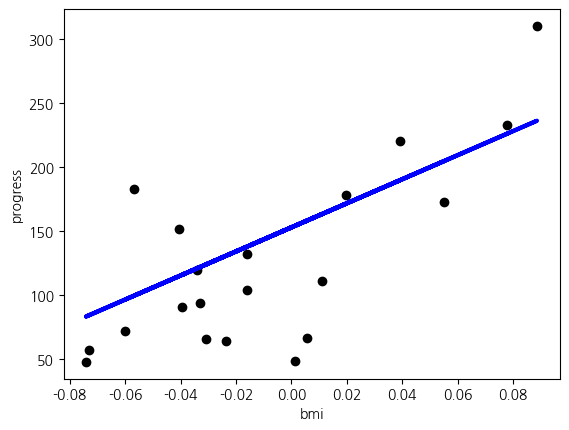

In [17]:
# visualization

plt.scatter(diabetes_X_test, diabetes_y_test,  color='black')
plt.plot(diabetes_X_test, y_pred, color='blue', linewidth=3)

plt.xlabel('bmi') 
plt.ylabel('progress')
plt.show()

## R2 (R-square, 결정계수) 계산

R² 점수를 계산하여 모델의 성능을 평가합니다. 1에 가까울수록 좋은 모델입니다.

In [18]:
print("결정계수 : {:.2f}".format(r2_score(diabetes_y_test, y_pred)))

결정계수 : 0.47


## RMSE (Root Mean Squared Error, 평균 제곱근 오차) 계산

RMSE는 예측값과 실제값의 차이를 측정하는 지표입니다. 
$$
\mathrm{RMSE}
=
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
\left( y_i - \hat{y}_i \right)^2
}
$$
- n: 샘플 수
- $y_i$: 실제값
- $ŷ_i$: 예측값
RMSE는 0에 가까울수록 좋은 모델이며, 실제값과 같은 단위를 가집니다.

In [19]:
# MSE (Mean Squared Error) 계산
mse = mean_squared_error(diabetes_y_test, y_pred)
# RMSE = √MSE
rmse = np.sqrt(mse)

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"RMSE는 예측값이 평균적으로 실제값과 약 {rmse:.2f} 정도 차이난다는 의미입니다.")

MSE: 2548.07
RMSE: 50.48
RMSE는 예측값이 평균적으로 실제값과 약 50.48 정도 차이난다는 의미입니다.


## Multivariate Linear Regression (다변수 선형회귀)

이제 모든 10개의 특성을 사용하여 다변수 회귀를 수행합니다. 더 많은 정보를 활용하여 예측 성능을 향상시킵니다.

In [20]:
# 10 개의 feature 를 사용
diabetes_X = df_diab[['age', 'sex','bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']].values
diabetes_X.shape

(442, 10)

전체 특성을 사용하여 데이터를 분할하고 모델을 학습시킵니다. 모든 특성을 활용하면 더 정확한 예측이 가능합니다.

In [21]:
# Split the data into training/testing sets
diabetes_X_train = diabetes_X[:-20]
diabetes_X_test = diabetes_X[-20:]

# Split the targets into training/testing sets
diabetes_y_train = diabetes.target[:-20]
diabetes_y_test = diabetes.target[-20:]

# Create linear regression object
regr = linear_model.LinearRegression()

# Train the model using the training sets
regr.fit(diabetes_X_train, diabetes_y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


전체 특성을 사용한 모델의 최종 성능을 R² 점수로 평가합니다. 단변수 회귀와 비교하여 성능 향상을 확인합니다.

In [22]:
# Make predictions using the testing set
diabetes_y_pred = regr.predict(diabetes_X_test)

# R2 계산 
print("결정계수: {:.2f}".format(r2_score(diabetes_y_test, diabetes_y_pred)))

결정계수: 0.59


## RMSE (Root Mean Squared Error, 평균 제곱근 오차) 계산

다변수 회귀 모델의 RMSE를 계산하여 단변수 회귀와 비교합니다.
RMSE가 작을수록 예측 오차가 작아 더 정확한 모델입니다.

In [23]:
# MSE (Mean Squared Error) 계산
mse_multivariate = mean_squared_error(diabetes_y_test, diabetes_y_pred)
# RMSE = √MSE
rmse_multivariate = np.sqrt(mse_multivariate)

print(f"MSE: {mse_multivariate:.2f}")
print(f"RMSE: {rmse_multivariate:.2f}")
print(f"\n단변수 회귀 RMSE: {rmse:.2f}")
print(f"다변수 회귀 RMSE: {rmse_multivariate:.2f}")
if rmse_multivariate < rmse:
    print(f"다변수 회귀가 RMSE가 {rmse - rmse_multivariate:.2f}만큼 더 작아 성능이 향상되었습니다.")
else:
    print(f"단변수 회귀가 더 좋은 성능을 보입니다.")

MSE: 2004.52
RMSE: 44.77

단변수 회귀 RMSE: 50.48
다변수 회귀 RMSE: 44.77
다변수 회귀가 RMSE가 5.71만큼 더 작아 성능이 향상되었습니다.
